# <span style="color:red"><center>Transformer Chatbot</center></span>

<center>Chatbot conversacional </center>

<figure>
<center>
<img src="../Imagenes/robot_chat.jpg" width="800" align="center"/>
</center>
</figure>


Fuente: [Pixabay](https://www.istockphoto.com/es/search/2/image?mediatype=&phrase=robot+chat&utm_source=pixabay&utm_medium=affiliate&utm_campaign=SRP_image_sponsored&utm_content=http%3A%2F%2Fpixabay.com%2Fes%2Fimages%2Fsearch%2Frobot+chat%2F&utm_term=robot+chat)

## <span style="color:blue">Referencias</span>

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/bryanlimy/tf2-transformer-chatbot/blob/master/tf2_tpu_transformer_chatbot.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/bryanlimy/tf2-transformer-chatbot/blob/master/tf2_tpu_transformer_chatbot.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

## <span style="color:blue">Contenido</span>

* [Introducción](#Introducción)
* [Importa-librerías](#Importa-librerías)
* [Hiperparámetros](Hiperparámetros)
* [Prepara el Dataset](Prepara-el-Dataset)
* [Atención](#Atención)
* [Transformer](#Transformer)
* [Entrenamiento del modelo](#Entrenamiento-del-modelo)
* [Evaluación y predicción](#Evaluación-y-predicción)
* [Resumen](#Resumen)


## <span style="color:blue">Introducción</span> 

En este tutorial entrenamos <a href="https://arxiv.org/pdf/1706.03762.pdf" class="external"> modelo Transformer </a> Pra que actúe como un chatbot. Este es un ejemplo avanzado que asume el conocimiento de [generación de texto](https://tensorflow.org/alpha/tutorials/text/text_generation), [atención](https://www.tensorflow.org/alpha/tutorials/text/nmt_with_attention) and [Transformer](https://www.tensorflow.org/alpha/tutorials/text/transformer).

La idea central detrás del modelo Transformer es la *autoatención*: la capacidad de prestar atención a diferentes posiciones de la secuencia de entrada para calcular una representación de esa secuencia. Transformer crea pilas de capas de autoatención y se explica a continuación en las secciones *Atención de producto de punto escalado* y *Atención de varios cabezales*.

Nota: La arquitectura del modelo es idéntica al ejemplo en [Transformer model for language understanding](https://www.tensorflow.org/alpha/tutorials/text/transformer), y demostramos cómo implementar el mismo modelo en el enfoque Funcional en lugar de subclases.

 * Cuaderno revisado para correr con Python 3.12.9 en un entorno local en VS code.

## <span style="color:blue">Importa librerías</span> 

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

import sys

#!pip install tensorflow==2.4.1
import tensorflow as tf

tf.random.set_seed(1234)
AUTO = tf.data.experimental.AUTOTUNE

%pip install -q --upgrade tensorflow-datasets==4.9.10
import tensorflow_datasets as tfds

import os
import re
import numpy as np
from time import time
import matplotlib.pyplot as plt

print("Tensorflow version {}".format(tf.__version__))

Note: you may need to restart the kernel to use updated packages.
Tensorflow version 2.21.0



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Inicialización de GPU / TPU 

En Google Colab, seleccione el hardware acelrador `TPU` o `GPU`.

In [2]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU {}'.format(tpu.cluster_spec().as_dict()['worker']))
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy()

print("REPLICAS: {}".format(strategy.num_replicas_in_sync))

REPLICAS: 1


## <span style="color:blue">Hiperparámetros</span> 

Para que este ejemplo sea pequeño y relativamente rápido, se han reducido los valores de *num_layers, d_model y units*. Consulte el [artículo](https://arxiv.org/abs/1706.03762) para conocer todas las demás versiones del transformador.

In [3]:
# Longitud máxima de sentencia
MAX_LENGTH = 40

# Número máximo de muestras para preprocesar
MAX_SAMPLES = 50000

# Para tf.data.Dataset
BATCH_SIZE = 64 * strategy.num_replicas_in_sync
BUFFER_SIZE = 20000

# Para el Transformer
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1

EPOCHS = 10 #40

## <span style="color:blue">Prepara el Dataset</span> 

Usaremos las conversaciones en películas y programas de televisión proporcionados por [Cornell Movie-Dialogs Corpus](https://www.cs.cornell.edu/~cristian/Cornell_Movie-Dialogs_Corpus.html), que contiene más de 220 mil intercambios conversacionales. entre más de 10k pares de personajes de películas, como nuestro conjunto de datos.

`movie_conversations.txt` contiene una lista de ID de conversación y `movie_lines.text` contiene el texto asociado con cada ID de conversación. Para obtener más información sobre el conjunto de datos, consulte el archivo README en el archivo zip.


In [4]:
import os

path_to_zip = tf.keras.utils.get_file(
    'cornell_movie_dialogs.zip',
    origin=
    'http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip',
    extract=True)

base_dir = os.path.dirname(path_to_zip)
dataset_name = "cornell movie-dialogs corpus"
candidate_paths = [
    os.path.join(base_dir, dataset_name),
    os.path.join(base_dir, "cornell_movie_dialogs_extracted", dataset_name),
]

path_to_dataset = next((path for path in candidate_paths if os.path.isdir(path)), None)
if path_to_dataset is None:
    raise FileNotFoundError(f"No se encontro el dataset en: {candidate_paths}")

path_to_movie_lines = os.path.join(path_to_dataset, 'movie_lines.txt')
path_to_movie_conversations = os.path.join(path_to_dataset,
                                           'movie_conversations.txt')

### Cargar y preprocesar datos

Para mantener este ejemplo simple y rápido, estamos limitando el número máximo de muestras de entrenamiento a `MAX_SAMPLES=25000` y la longitud máxima de la oración a `MAX_LENGTH=40`.

Preprocesamos nuestro conjunto de datos en el siguiente orden:
* Extraiga los pares de conversación `MAX_SAMPLES` en la lista de `preguntas` y `respuestas.
* Preprocesar cada oración eliminando caracteres especiales en cada oración.
* Crear tokenizador (asignar texto a ID e ID a texto) usando [TensorFlow Datasets SubwordTextEncoder](https://www.tensorflow.org/datasets/api_docs/python/tfds/features/text/SubwordTextEncoder).
* Tokenice cada oración y agregue `START_TOKEN` y `END_TOKEN` para indicar el comienzo y el final de cada oración.
* Filtre la oración que tenga más de tokens `MAX_LENGTH`.
* Rellene las oraciones tokenizadas a `MAX_LENGTH`

In [5]:
import re

def preprocess_sentence(sentence):
  sentence = sentence.lower().strip()
  # creando un espacio entre una palabra y la puntuación que le sigue
  # ejemplo: "he is a boy." => "he is a boy ."
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)
  # remueve contracciones
  sentence = re.sub(r"i'm", "i am", sentence)
  sentence = re.sub(r"he's", "he is", sentence)
  sentence = re.sub(r"she's", "she is", sentence)
  sentence = re.sub(r"it's", "it is", sentence)
  sentence = re.sub(r"that's", "that is", sentence)
  sentence = re.sub(r"what's", "that is", sentence)
  sentence = re.sub(r"where's", "where is", sentence)
  sentence = re.sub(r"how's", "how is", sentence)
  sentence = re.sub(r"\'ll", " will", sentence)
  sentence = re.sub(r"\'ve", " have", sentence)
  sentence = re.sub(r"\'re", " are", sentence)
  sentence = re.sub(r"\'d", " would", sentence)
  sentence = re.sub(r"\'re", " are", sentence)
  sentence = re.sub(r"won't", "will not", sentence)
  sentence = re.sub(r"can't", "cannot", sentence)
  sentence = re.sub(r"n't", " not", sentence)
  sentence = re.sub(r"n'", "ng", sentence)
  sentence = re.sub(r"'bout", "about", sentence)
  # reemplazando todo con espacio excepto (a-z, A-Z, ".", "?", "!", ",")
  sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence


def load_conversations():
  # diccionario de id de línea a texto
  id2line = {}
  with open(path_to_movie_lines, errors='ignore') as file:
    lines = file.readlines()
  for line in lines:
    parts = line.replace('\n', '').split(' +++$+++ ')
    id2line[parts[0]] = parts[4]

  inputs, outputs = [], []
  with open(path_to_movie_conversations, 'r') as file:
    lines = file.readlines()
  for line in lines:
    parts = line.replace('\n', '').split(' +++$+++ ')
    # obtener conversación en una lista de ID de línea
    conversation = [line[1:-1] for line in parts[3][1:-1].split(', ')]
    for i in range(len(conversation) - 1):
      inputs.append(preprocess_sentence(id2line[conversation[i]]))
      outputs.append(preprocess_sentence(id2line[conversation[i + 1]]))
      if len(inputs) >= MAX_SAMPLES:
        return inputs, outputs
  return inputs, outputs


questions, answers = load_conversations()

In [6]:
# Revisión del archivo de líneas
id2line = {}
with open(path_to_movie_lines, errors='ignore') as file:
    lines = file.readlines()
print(len(lines))
for i in range(10):
  print(lines[i])

304713
L1045 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ They do not!

L1044 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON +++$+++ They do to!

L985 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ I hope so.

L984 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON +++$+++ She okay?

L925 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ Let's go.

L924 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON +++$+++ Wow

L872 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ Okay -- you're gonna need to learn how to lie.

L871 +++$+++ u2 +++$+++ m0 +++$+++ CAMERON +++$+++ No

L870 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ I'm kidding.  You know how sometimes you just become this "persona"?  And you don't know how to quit?

L869 +++$+++ u0 +++$+++ m0 +++$+++ BIANCA +++$+++ Like my fear of wearing pastels?



In [7]:
# Verificación de estructura: esta salida debe mostrar 5 campos.
parts = lines[0].strip().split(' +++$+++ ')
assert len(parts) == 5, f"Formato inesperado en movie_lines.txt: {parts}"
id2line[parts[0]] = parts[-1]
print("OK - línea separada:", parts)
print("OK - ejemplo id -> texto:", {parts[0]: id2line[parts[0]]})

OK - línea separada: ['L1045', 'u0', 'm0', 'BIANCA', 'They do not!']
OK - ejemplo id -> texto: {'L1045': 'They do not!'}


In [8]:
# Revisión archivo de conversaciones
with open(path_to_movie_conversations, 'r') as file:
    lines = file.readlines()
  
for i in range(10):
  print(lines[i])

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L194', 'L195', 'L196', 'L197']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L198', 'L199']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L200', 'L201', 'L202', 'L203']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L204', 'L205', 'L206']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L207', 'L208']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L271', 'L272', 'L273', 'L274', 'L275']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L276', 'L277']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L280', 'L281']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L363', 'L364']

u0 +++$+++ u2 +++$+++ m0 +++$+++ ['L365', 'L366']



In [9]:
['L271', 'L272', 'L273', 'L274', 'L275']

['L271', 'L272', 'L273', 'L274', 'L275']

In [10]:
print('Muestra de una pregunta: {}'.format(questions[20]))
print('Muestra de una respuesta: {}'.format(answers[20]))

Muestra de una pregunta: i really , really , really wanna go , but i cannot . not unless my sister goes .
Muestra de una respuesta: i am working on it . but she does not seem to be going for him .


In [11]:
# tensorflow_datasets se instala e importa en la celda inicial.


In [12]:
# TensorFlow se importa en la celda inicial.

In [13]:
# tensorflow_datasets ya está importado como tfds.

In [14]:
#import tensorflow_datasets as tfds
# Cree un tokenizador usando tfds para preguntas y respuestas
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    questions + answers, target_vocab_size=2**13)

# Definir token de inicio y final para indicar el inicio y el final de una oración
START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]

# Tamaño del vocabulario más token de inicio y finalización
VOCAB_SIZE = tokenizer.vocab_size + 2

In [15]:
print('Pregunta de muestra tokenizada: {}'.format(tokenizer.encode(questions[20])))

Pregunta de muestra tokenizada: [4, 271, 3, 271, 3, 141, 385, 173, 3, 40, 4, 612, 2, 11, 865, 30, 2021, 3086, 1]


In [16]:
# Tokenizar, filtrar and rellenar sentencias
def tokenize_and_filter(inputs, outputs):
  tokenized_inputs, tokenized_outputs = [], []
  
  for (sentence1, sentence2) in zip(inputs, outputs):
    # tokeniza sentencia
    sentence1 = START_TOKEN + tokenizer.encode(sentence1) + END_TOKEN
    sentence2 = START_TOKEN + tokenizer.encode(sentence2) + END_TOKEN
    # verificar la longitud máxima de la oración tokenizada
    if len(sentence1) <= MAX_LENGTH and len(sentence2) <= MAX_LENGTH:
      tokenized_inputs.append(sentence1)
      tokenized_outputs.append(sentence2)
  
  # rellenar oraciones tokenizadas
  tokenized_inputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_inputs, maxlen=MAX_LENGTH, padding='post')
  tokenized_outputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_outputs, maxlen=MAX_LENGTH, padding='post')
  
  return tokenized_inputs, tokenized_outputs


questions, answers = tokenize_and_filter(questions, answers)

In [17]:
print('Tamaño del vocabulario: {}'.format(VOCAB_SIZE))
print('Numbero de muestras: {}'.format(len(questions)))

Tamaño del vocabulario: 8278
Numbero de muestras: 44134


### Crea el  `tf.data.Dataset`

Vamos a utilizar [tf.data.Dataset API](https://www.tensorflow.org/api_docs/python/tf/data) para construir nuestra línea de entrada con el fin de utilizar funciones como el almacenamiento en caché y la captación previa para acelerar el proceso de formación.

El transformador es un modelo autorregresivo: hace predicciones una parte a la vez y usa su salida hasta el momento para decidir qué hacer a continuación.

Durante la capacitación, este ejemplo utiliza la fuerza del maestro. La fuerza del profesor pasa la salida real al siguiente paso de tiempo, independientemente de lo que prediga el modelo en el paso de tiempo actual.

A medida que el transformador predice cada palabra, la autoatención le permite mirar las palabras anteriores en la secuencia de entrada para predecir mejor la siguiente palabra.

Para evitar que el modelo alcance el resultado esperado, el modelo utiliza una máscara de anticipación.

El objetivo se divide en `decoder_inputs` que se rellenan como una entrada al decodificador y `cropped_targets` para calcular nuestra pérdida y precisión.

In [18]:
# decoder inputs use the previous target as input
# remove START_TOKEN from targets
# Keras 3 espera la etiqueta como tensor porque el modelo tiene una sola salida.
dataset = tf.data.Dataset.from_tensor_slices((
    {
        'inputs': questions,
        'dec_inputs': answers[:, :-1]
    },
    answers[:, 1:],
))

dataset = dataset.cache()
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)

## <span style="color:blue">Atención</span> 

### Producto punto escalado Atención

La función de atención de producto punto escalado utilizada por el transformador toma tres entradas: Q (consulta), K (clave), V (valor). La ecuación utilizada para calcular los pesos de atención es:

$$\Large{Atención(Q, K, V) = softmax_k(\frac{QK^T}{\sqrt{d_k}}) V} $$

Como la normalización softmax se realiza en la `clave`, sus valores deciden la cantidad de importancia que se le da a la `consulta`.

La salida representa la multiplicación de los pesos de atención y el vector `valor`. Esto asegura que las palabras en las que queremos centrarnos se mantengan como están y las palabras irrelevantes se eliminen.

La atención del producto escalar se escala por un factor de raíz cuadrada de la profundidad. Esto se hace porque para valores grandes de profundidad, el producto escalar crece en magnitud empujando la función softmax donde tiene pequeños gradientes que dan como resultado un softmax muy duro.

Por ejemplo, considere que `query` y `key` tienen una media de 0 y una varianza de 1. Su multiplicación de matriz tendrá una media de 0 y una varianza de `dk`. Por lo tanto, *la raíz cuadrada de `dk`* se usa para escalar (y no cualquier otro número) porque el matmul de `query` y `key` debe tener una media de 0 y una varianza de 1, de modo que obtengamos un softmax más suave. .

La máscara se multiplica con *-1e9 (cerca del infinito negativo).* Esto se hace porque la máscara se suma con la multiplicación de matriz escalada de `query` y `key` y se aplica inmediatamente antes de un softmax. El objetivo es poner a cero estas celdas, y las entradas negativas grandes a softmax están cerca de cero en la salida.

In [19]:
def scaled_dot_product_attention(query, key, value, mask):
  """Calculate the attention weights. """
  matmul_qk = tf.matmul(query, key, transpose_b=True)

  # scale matmul_qk
  depth = tf.cast(tf.shape(key)[-1], tf.float32)
  logits = matmul_qk / tf.math.sqrt(depth)

  # add the mask to zero out padding tokens
  if mask is not None:
    logits += (mask * -1e9)

  # softmax is normalized on the last axis (seq_len_k)
  attention_weights = tf.nn.softmax(logits, axis=-1)

  output = tf.matmul(attention_weights, value)

  return output

### Cabeza Multi-atención

<img src="https://www.tensorflow.org/images/tutorials/transformer/multi_head_attention.png" width="500" alt="multi-head attention">

La atención de múltiples cabezas consta de cuatro partes:
* Capas lineales y divididas en cabezas.
* Atención de producto punto escalado.
* Concatenación de cabezas.
* Capa lineal final.

Cada bloque de atención de varios cabezales recibe tres entradas; Q (consulta), K (clave), V (valor). Estos se colocan a través de capas lineales (Densas) y se dividen en múltiples cabezas.

El `scaled_dot_product_attention` definido anteriormente se aplica a cada cabeza (transmitido por eficiencia). Se debe utilizar una máscara adecuada en el paso de atención. Luego, la salida de atención para cada cabeza se concatena (usando `tf.transpose` y `tf.reshape`) y se pasa por una capa final `Dense`.

En lugar de un solo encabezado de atención, `consulta`, `clave` y `valor` se dividen en múltiples encabezados porque permite que el modelo atienda conjuntamente la información en diferentes posiciones desde diferentes espacios de representación. Después de la división, cada cabeza tiene una dimensionalidad reducida, por lo que el costo total de cómputo es el mismo que el de la atención de una sola cabeza con dimensionalidad completa.

In [20]:
class MultiHeadAttention(tf.keras.layers.Layer):

  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)
    self.num_heads = num_heads
    self.d_model = d_model

    assert d_model % self.num_heads == 0

    self.depth = d_model // self.num_heads

    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    self.dense = tf.keras.layers.Dense(units=d_model)
  
  def get_config(self):
        config = super(MultiHeadAttention,self).get_config()
        config.update({
            'num_heads':self.num_heads,
            'd_model':self.d_model,
        })
        return config

  def split_heads(self, inputs, batch_size):
    inputs = tf.keras.layers.Lambda(lambda inputs:tf.reshape(
        inputs, shape=(batch_size, -1, self.num_heads, self.depth)))(inputs)
    return tf.keras.layers.Lambda(lambda inputs: tf.transpose(inputs, perm=[0, 2, 1, 3]))(inputs)

  def call(self, inputs):
    query, key, value, mask = inputs['query'], inputs['key'], inputs[
        'value'], inputs['mask']
    batch_size = tf.shape(query)[0]

    # linear layers
    query = self.query_dense(query)
    key = self.key_dense(key)
    value = self.value_dense(value)

    # split heads
    query = self.split_heads(query, batch_size)
    key = self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size)

    # Producto escalr atencional
    scaled_attention = scaled_dot_product_attention(query, key, value, mask)
    scaled_attention = tf.keras.layers.Lambda(lambda scaled_attention: tf.transpose(
        scaled_attention, perm=[0, 2, 1, 3]))(scaled_attention)

    # concatenación de las cabezas de atención
    concat_attention = tf.keras.layers.Lambda(lambda scaled_attention: tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model)))(scaled_attention)

    # Capa lineal final
    outputs = self.dense(concat_attention)

    return outputs    

## <span style="color:blue"> Transformer</span>

### Enmascaramiento

`create_padding_mask` y `create_look_ahead` son funciones auxiliares para crear máscaras para enmascarar tokens acolchados, vamos a utilizar estas funciones auxiliares como capas `tf.keras.layers.Lambda`.

Enmascare todos los tokens de relleno (valor `0`) en el lote para asegurarse de que el modelo no trate el relleno como entrada.

In [21]:
def create_padding_mask(x):
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)
  # (batch_size, 1, 1, sequence length)
  return mask[:, tf.newaxis, tf.newaxis, :]

In [22]:
print(create_padding_mask(tf.constant([[1, 2, 0, 3, 0], [0, 0, 0, 4, 5]])))

tf.Tensor(
[[[[0. 0. 1. 0. 1.]]]


 [[[1. 1. 1. 0. 0.]]]], shape=(2, 1, 1, 5), dtype=float32)


Máscara de anticipación para enmascarar los tokens futuros en una secuencia.
También enmascaramos tokens de pad.

es decir, para predecir la tercera palabra, solo se usarán la primera y la segunda palabra

In [23]:
def create_look_ahead_mask(x):
  seq_len = tf.shape(x)[1]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
  padding_mask = create_padding_mask(x)
  return tf.maximum(look_ahead_mask, padding_mask)

In [24]:
import tensorflow as tf

In [25]:
seq_len = 5
tf.linalg.band_part(tf.ones((seq_len, seq_len)), 0, -1)

<tf.Tensor: shape=(5, 5), dtype=float32, numpy=
array([[1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1.]], dtype=float32)>

In [26]:
print(create_look_ahead_mask(tf.constant([[1, 2, 0, 4, 5]])))

tf.Tensor(
[[[[0. 1. 1. 1. 1.]
   [0. 0. 1. 1. 1.]
   [0. 0. 1. 1. 1.]
   [0. 0. 1. 0. 1.]
   [0. 0. 1. 0. 0.]]]], shape=(1, 1, 5, 5), dtype=float32)


### Codificación posicional

Dado que este modelo no contiene recurrencia ni convolución, se agrega codificación posicional para brindarle al modelo información sobre la posición relativa de las palabras en la oración.

El vector de codificación posicional se agrega al vector de incrustación. Las incrustaciones representan un token en un espacio d-dimensional donde los tokens con un significado similar estarán más cerca unos de otros. Pero las incrustaciones no codifican la posición relativa de las palabras en una oración. Entonces, después de agregar la codificación posicional, las palabras estarán más cerca entre sí en función de la *similitud de su significado y su posición en la oración*, en el espacio d-dimensional.

Consulte el cuaderno sobre [codificación posicional](https://github.com/tensorflow/examples/blob/master/community/en/position_encoding.ipynb) para obtener más información al respecto. La fórmula para calcular la codificación posicional es la siguiente:

$$\Large{PE_{(pos, 2i)} = sin(pos / 10000^{2i / d_{modelo}})} $$
$$\Large{PE_{(pos, 2i+1)} = cos(pos / 10000^{2i / d_{modelo}})} $$

In [27]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.position = position  # Store as instance attributes for get_config
        self.d_model = d_model
        self.pos_encoding = self.positional_encoding(position, d_model)
    
    def get_config(self):
        config = super(PositionalEncoding, self).get_config()
        config.update({
            'position': self.position,
            'd_model': self.d_model,
        })
        return config

    def get_angles(self, position, i, d_model):
        angles = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
            i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
            d_model=d_model)
        
        # Apply sin to even indices, cos to odd indices
        sines = tf.math.sin(angle_rads[:, 0::2])
        cosines = tf.math.cos(angle_rads[:, 1::2])

        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

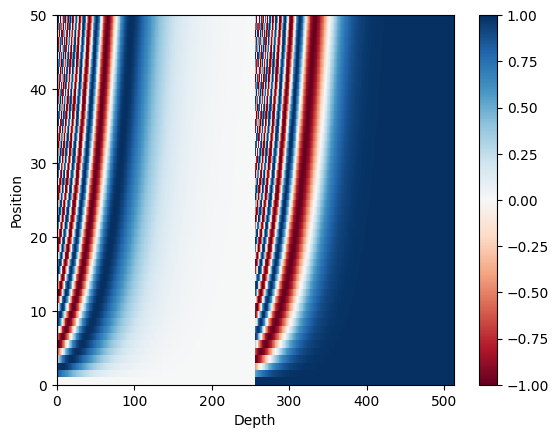

In [28]:
sample_pos_encoding = PositionalEncoding(50, 512)

plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('Depth')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### Capa del codificador

Cada capa de codificador consta de subcapas:

1. Atención multicabezal (con máscara de relleno)
2. 2 capas densas seguidas de abandono

Cada una de estas subcapas tiene una conexión residual a su alrededor seguida de una normalización de capa. Las conexiones residuales ayudan a evitar el problema del gradiente de fuga en las redes profundas.

La salida de cada subcapa es `LayerNorm(x + Sublayer(x))`. La normalización se realiza en el eje `d_model` (último).

In [29]:
def encoder_layer(units, d_model, num_heads, dropout, name="encoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  attention = MultiHeadAttention(
      d_model, num_heads, name="attention")({
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': padding_mask
      })
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)
  add_attention = tf.keras.layers.add([inputs,attention])
  attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add_attention)

  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  add_attention = tf.keras.layers.add([attention,outputs])
  outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add_attention)

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)

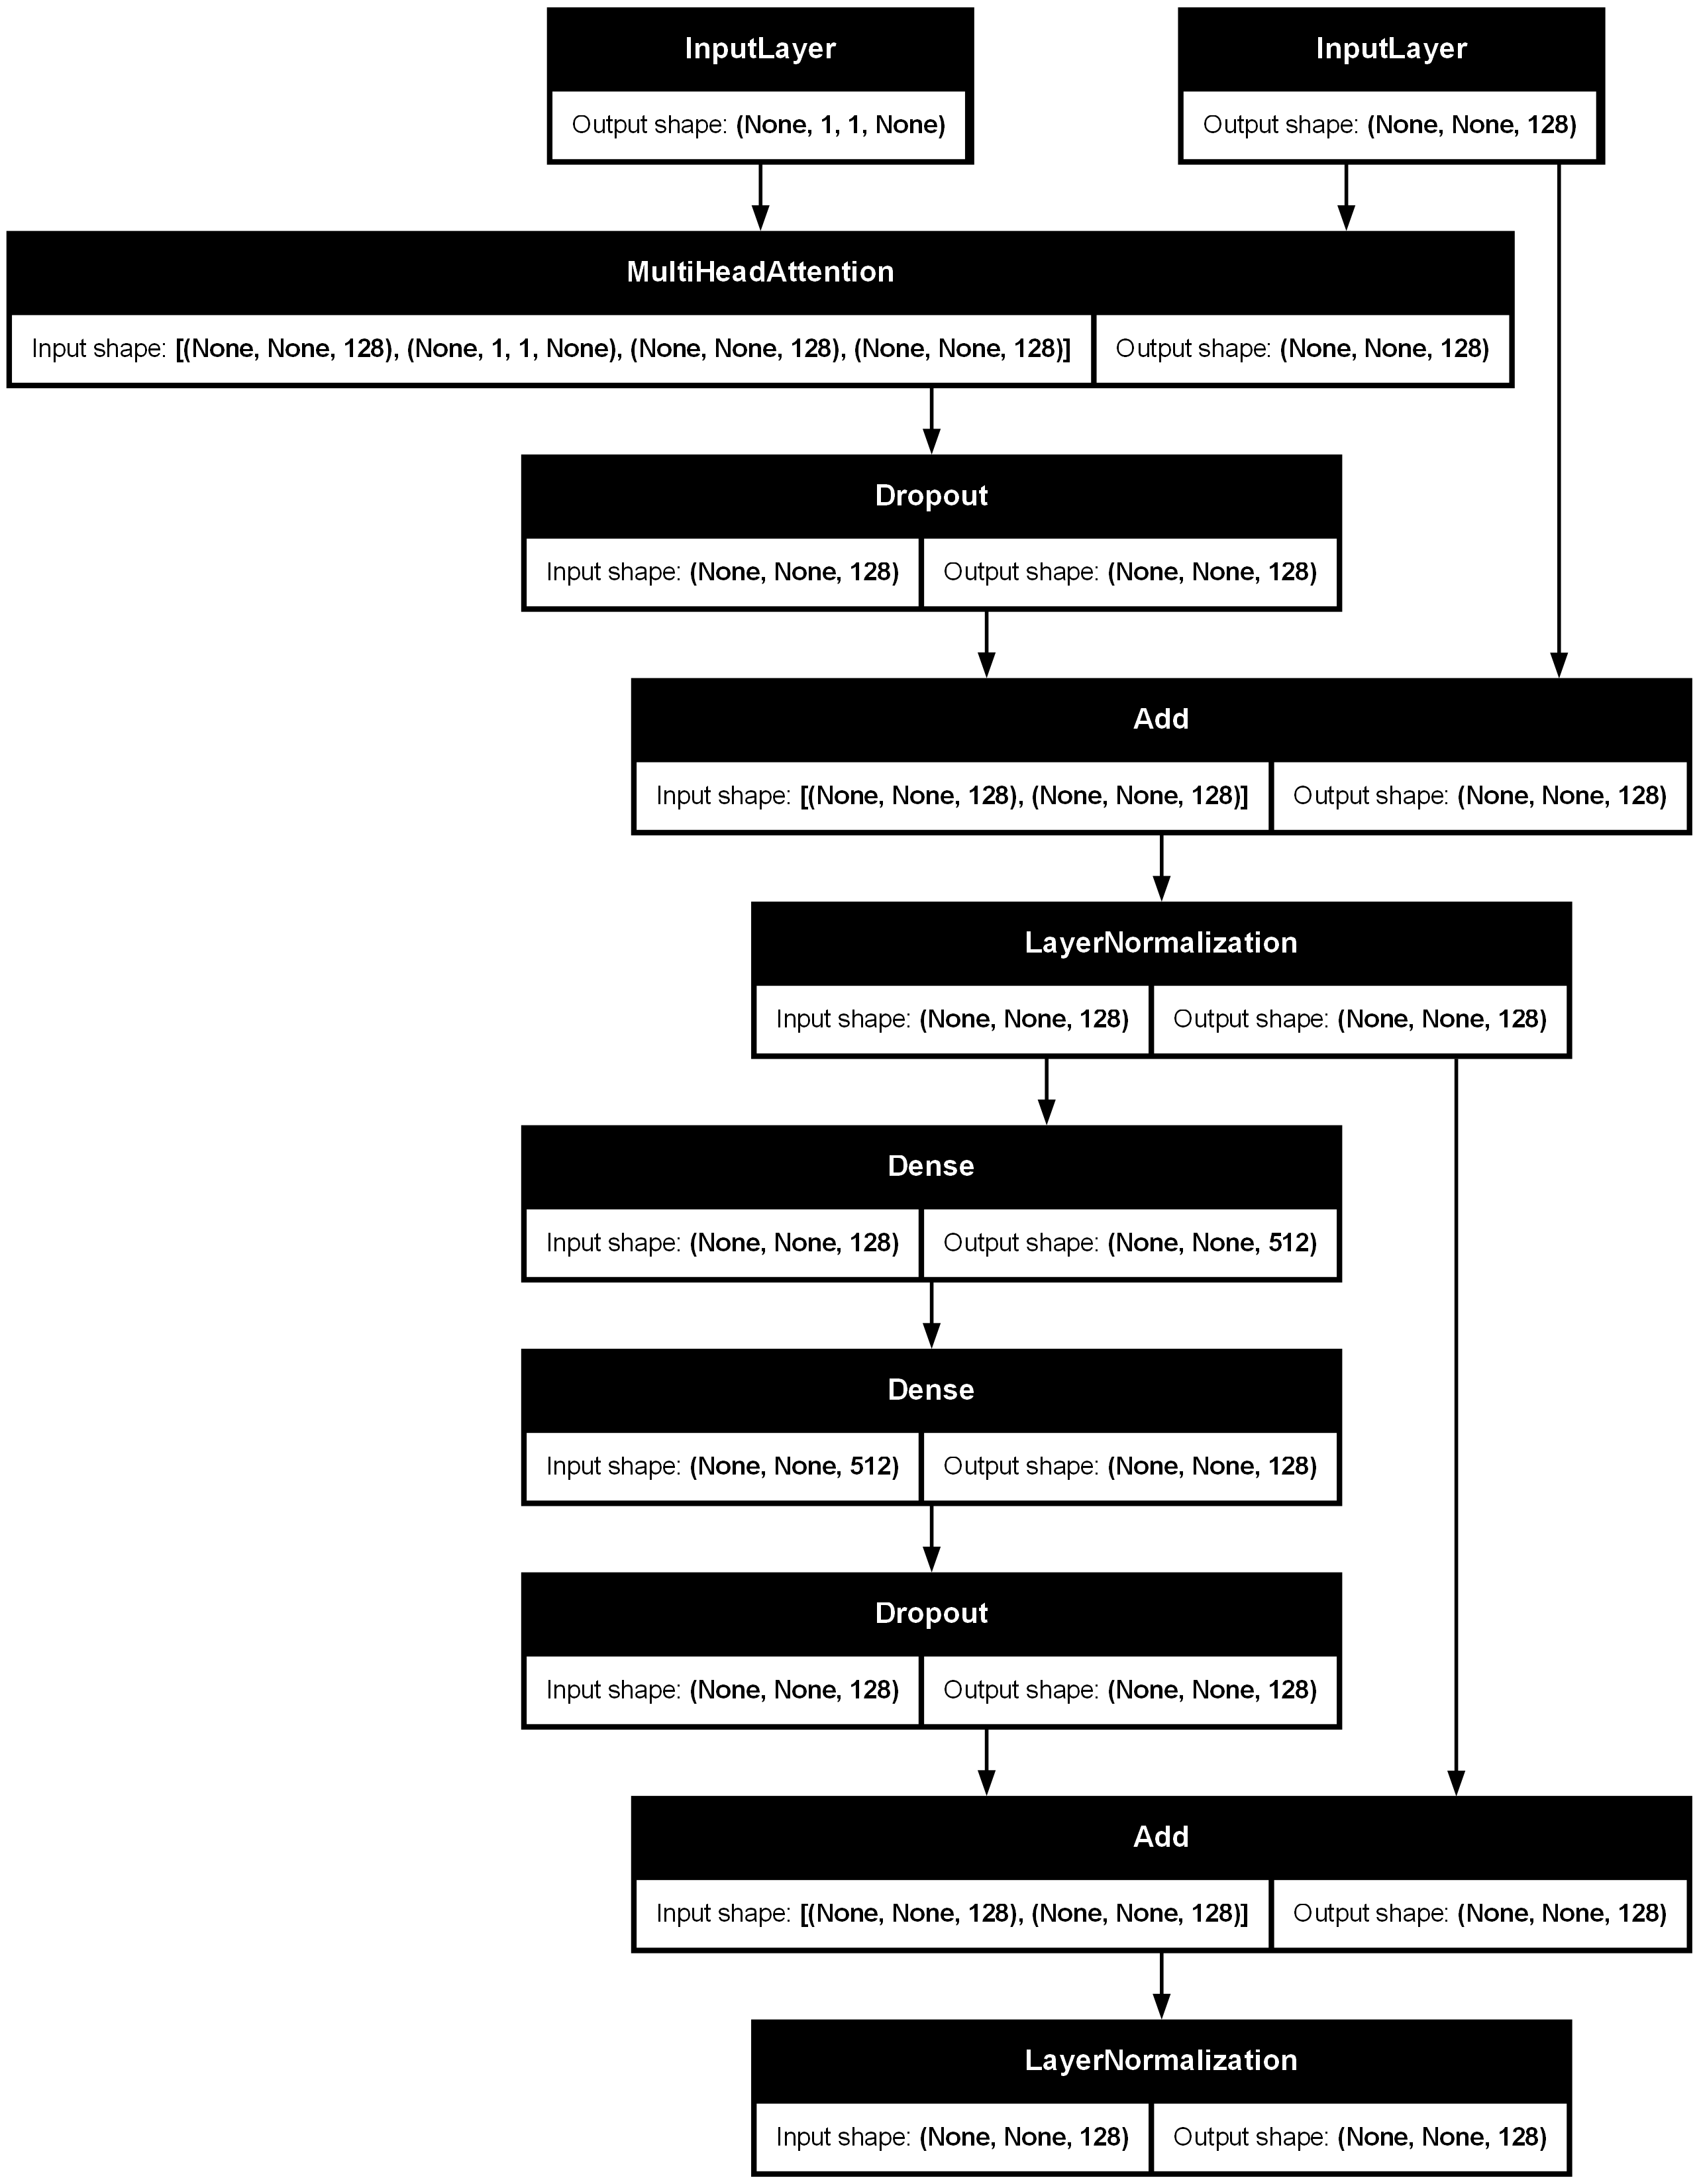

In [30]:
sample_encoder_layer = encoder_layer(
    units=512,
    d_model=128,
    num_heads=4,
    dropout=0.3,
    name="sample_encoder_layer")

tf.keras.utils.plot_model(
    sample_encoder_layer, to_file='encoder_layer.png', show_shapes=True)

### Codificador

El codificador consta de:
1. Incorporación de entrada
2. Codificación posicional
3. Capas de codificador `num_layers`

La entrada se somete a una incrustación que se suma con la codificación posicional. La salida de esta suma es la entrada a las capas del codificador. La salida del codificador es la entrada al decodificador.

In [31]:
def encoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name="encoder"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings = tf.keras.layers.Lambda(
      lambda x: x * tf.math.sqrt(tf.cast(d_model, tf.float32)),
      name="embedding_scale")(embeddings)
  embeddings = PositionalEncoding(vocab_size,d_model)(embeddings)

  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  for i in range(num_layers):
    outputs = encoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name="encoder_layer_{}".format(i),
    )([outputs, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, padding_mask], outputs=outputs, name=name)

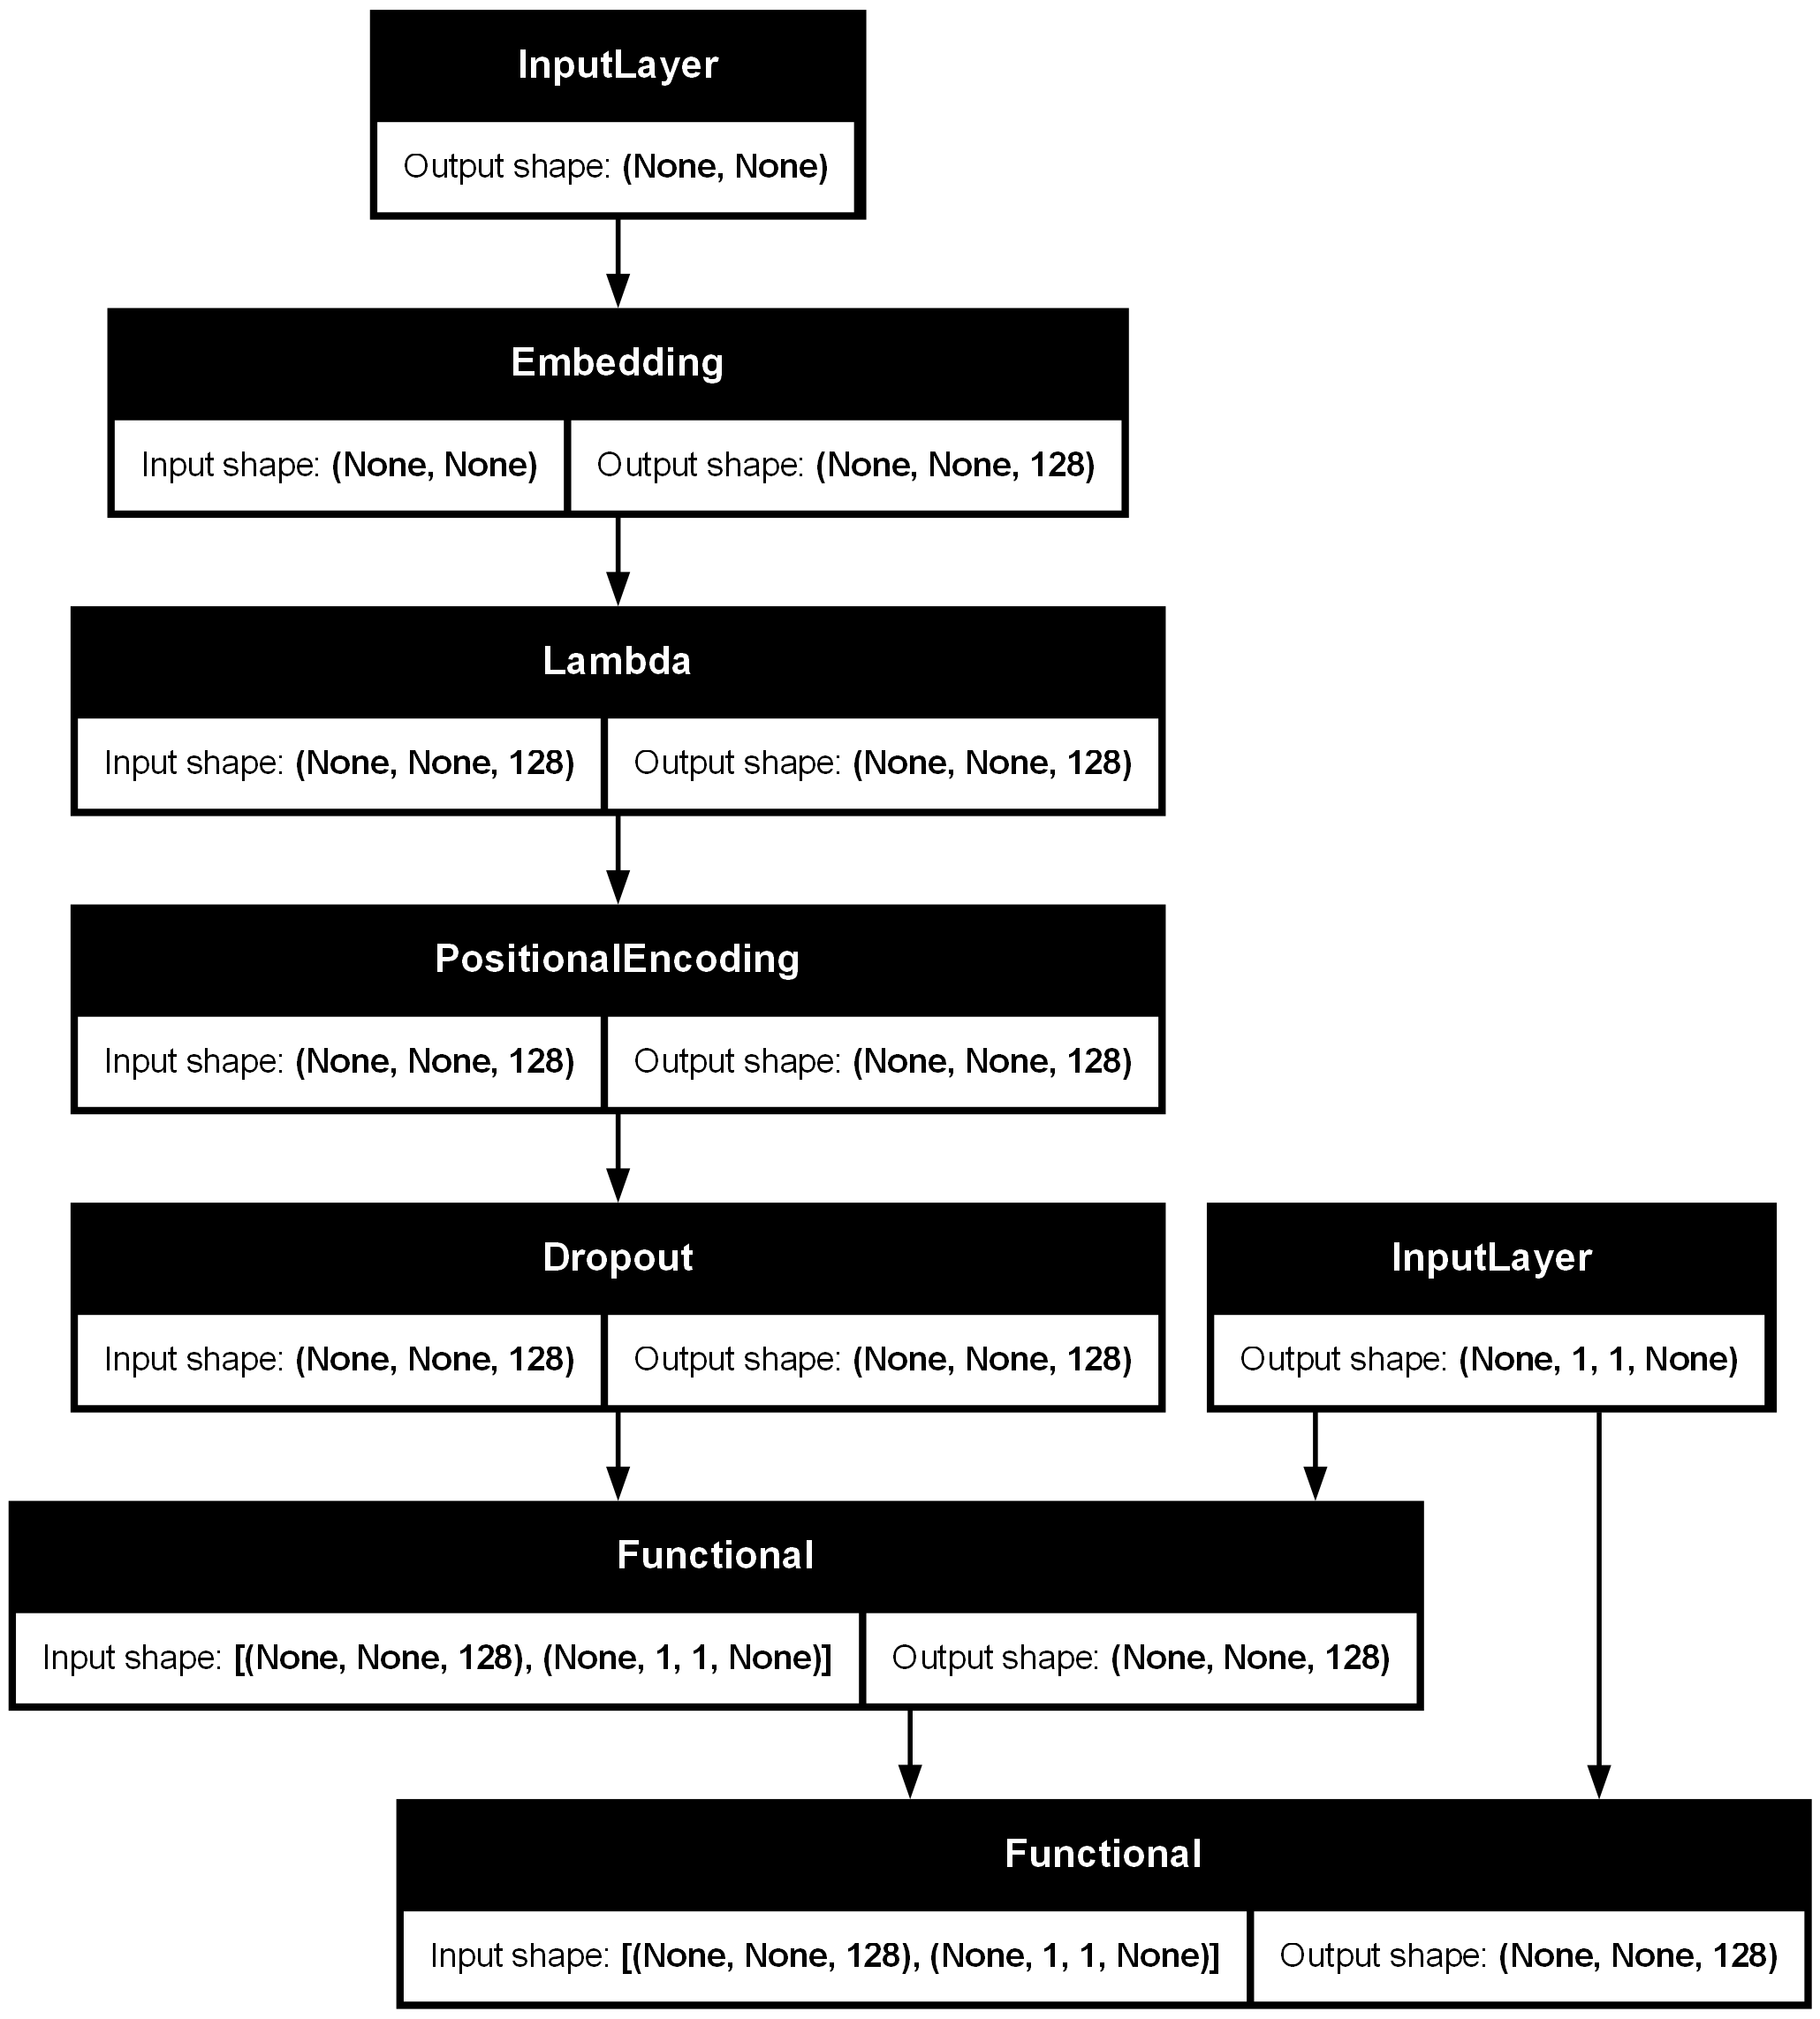

In [32]:
sample_encoder = encoder(
    vocab_size=8192,
    num_layers=2,
    units=512,
    d_model=128,
    num_heads=4,
    dropout=0.3,
    name="sample_encoder")

tf.keras.utils.plot_model(
   sample_encoder, to_file='encoder.png', show_shapes=True)

### Capa decodificadora

Cada capa del decodificador consta de subcapas:

1. Atención multicabezal enmascarada (con máscara de anticipación y máscara de relleno)
2. Atención multicabezal (con máscara de relleno). `value` y `key` reciben la *salida del codificador* como entradas. `query` recibe el *resultado de la subcapa de atención de múltiples cabezas enmascarada.*
3. 2 capas densas seguidas de abandono

Cada una de estas subcapas tiene una conexión residual a su alrededor seguida de una normalización de capa. La salida de cada subcapa es `LayerNorm(x + Sublayer(x))`. La normalización se realiza en el eje `d_model` (último).

Como `query` recibe la salida del primer bloque de atención del decodificador y `key` recibe la salida del codificador, los pesos de atención representan la importancia otorgada a la entrada del decodificador en función de la salida del codificador. En otras palabras, el decodificador predice la siguiente palabra mirando la salida del codificador y atendiendo automáticamente a su propia salida. Vea la demostración anterior en la sección de atención del producto escalar escalado.

In [33]:
def decoder_layer(units, d_model, num_heads, dropout, name="decoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name="look_ahead_mask")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': look_ahead_mask
      })
  add_attention = tf.keras.layers.add([attention1,inputs])    
  attention1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add_attention)

  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query': attention1,
          'key': enc_outputs,
          'value': enc_outputs,
          'mask': padding_mask
      })
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  add_attention = tf.keras.layers.add([attention2,attention1])
  attention2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add_attention)

  outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  add_attention = tf.keras.layers.add([outputs,attention2])
  outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(add_attention)

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)

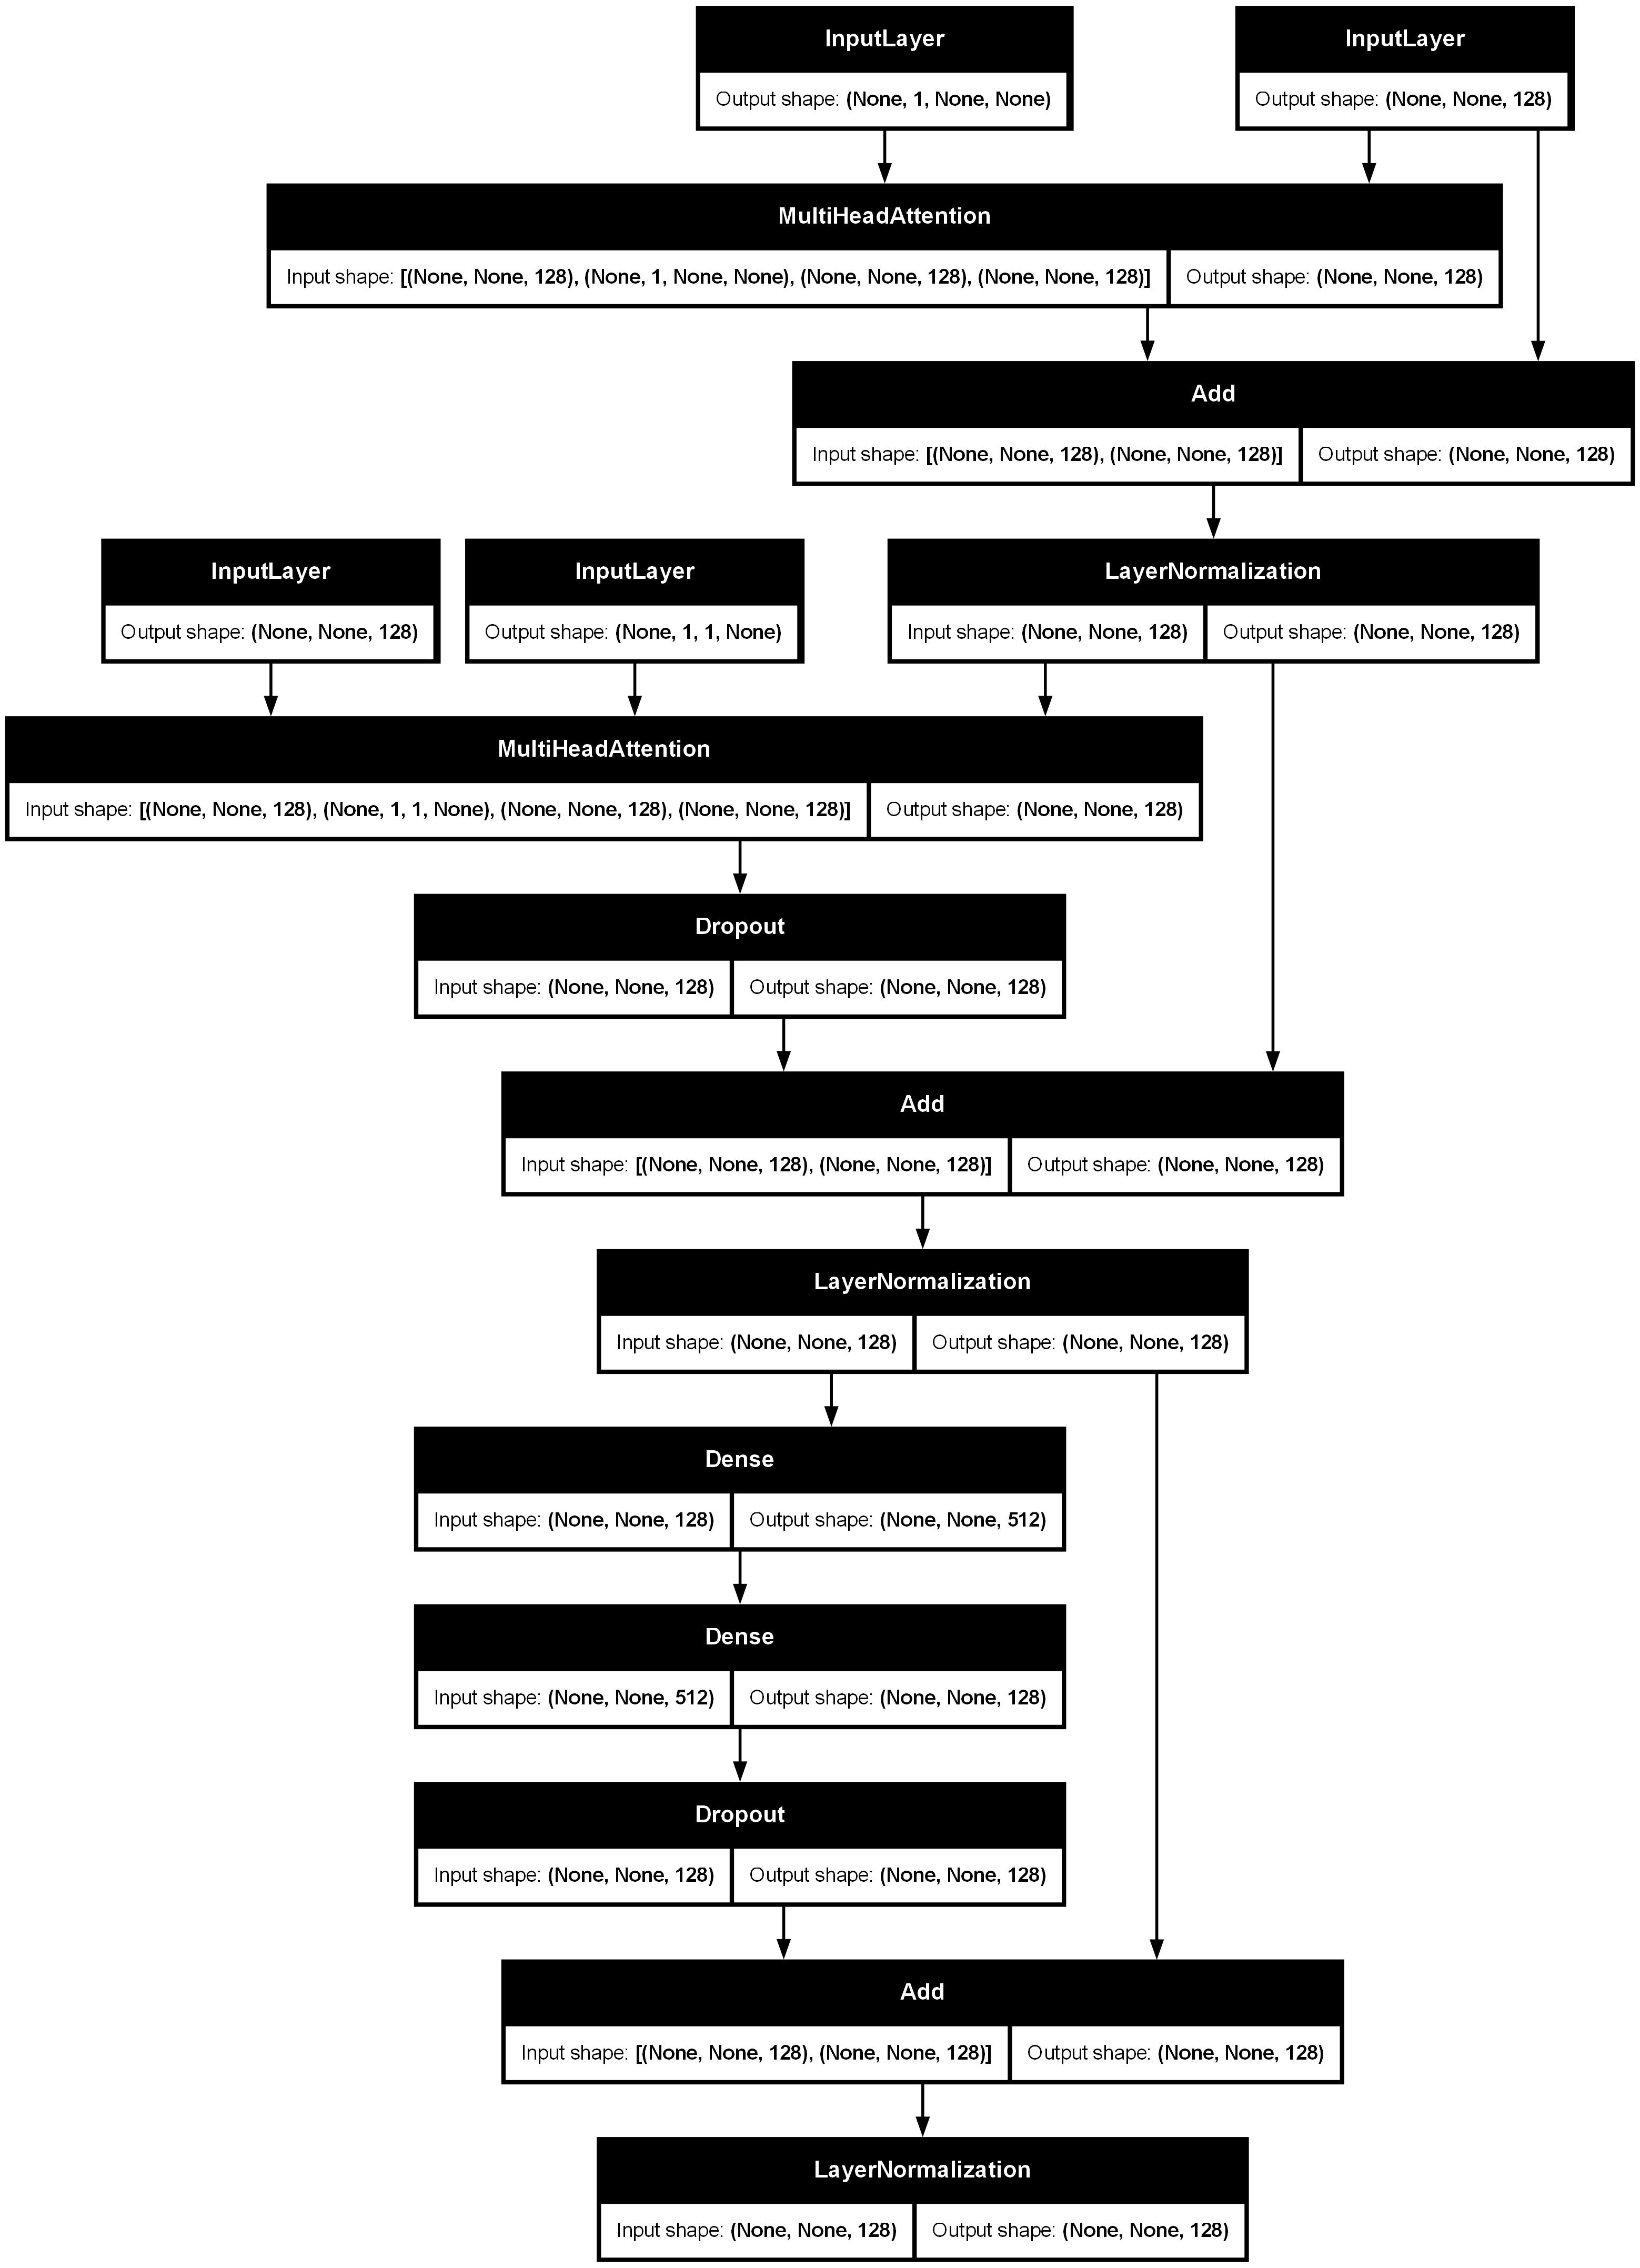

In [34]:
sample_decoder_layer = decoder_layer(
    units=512,
    d_model=128,
    num_heads=4,
    dropout=0.3,
    name="sample_decoder_layer")

tf.keras.utils.plot_model(
    sample_decoder_layer, to_file='decoder_layer.png', show_shapes=True)

### Decodificador

El decodificador consta de:
1. Incrustación de salida
2. Codificación posicional
3. N capas decodificadoras

El objetivo se somete a una incrustación que se suma con la codificación posicional. La salida de esta suma es la entrada a las capas del decodificador. La salida del decodificador es la entrada a la capa lineal final.

In [35]:
def decoder(vocab_size,
            num_layers,
            units,
            d_model,
            num_heads,
            dropout,
            name='decoder'):
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name='look_ahead_mask')
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')
  
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings = tf.keras.layers.Lambda(
      lambda x: x * tf.math.sqrt(tf.cast(d_model, tf.float32)),
      name="embedding_scale")(embeddings)
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  for i in range(num_layers):
    outputs = decoder_layer(
        units=units,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name='decoder_layer_{}'.format(i),
    )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)

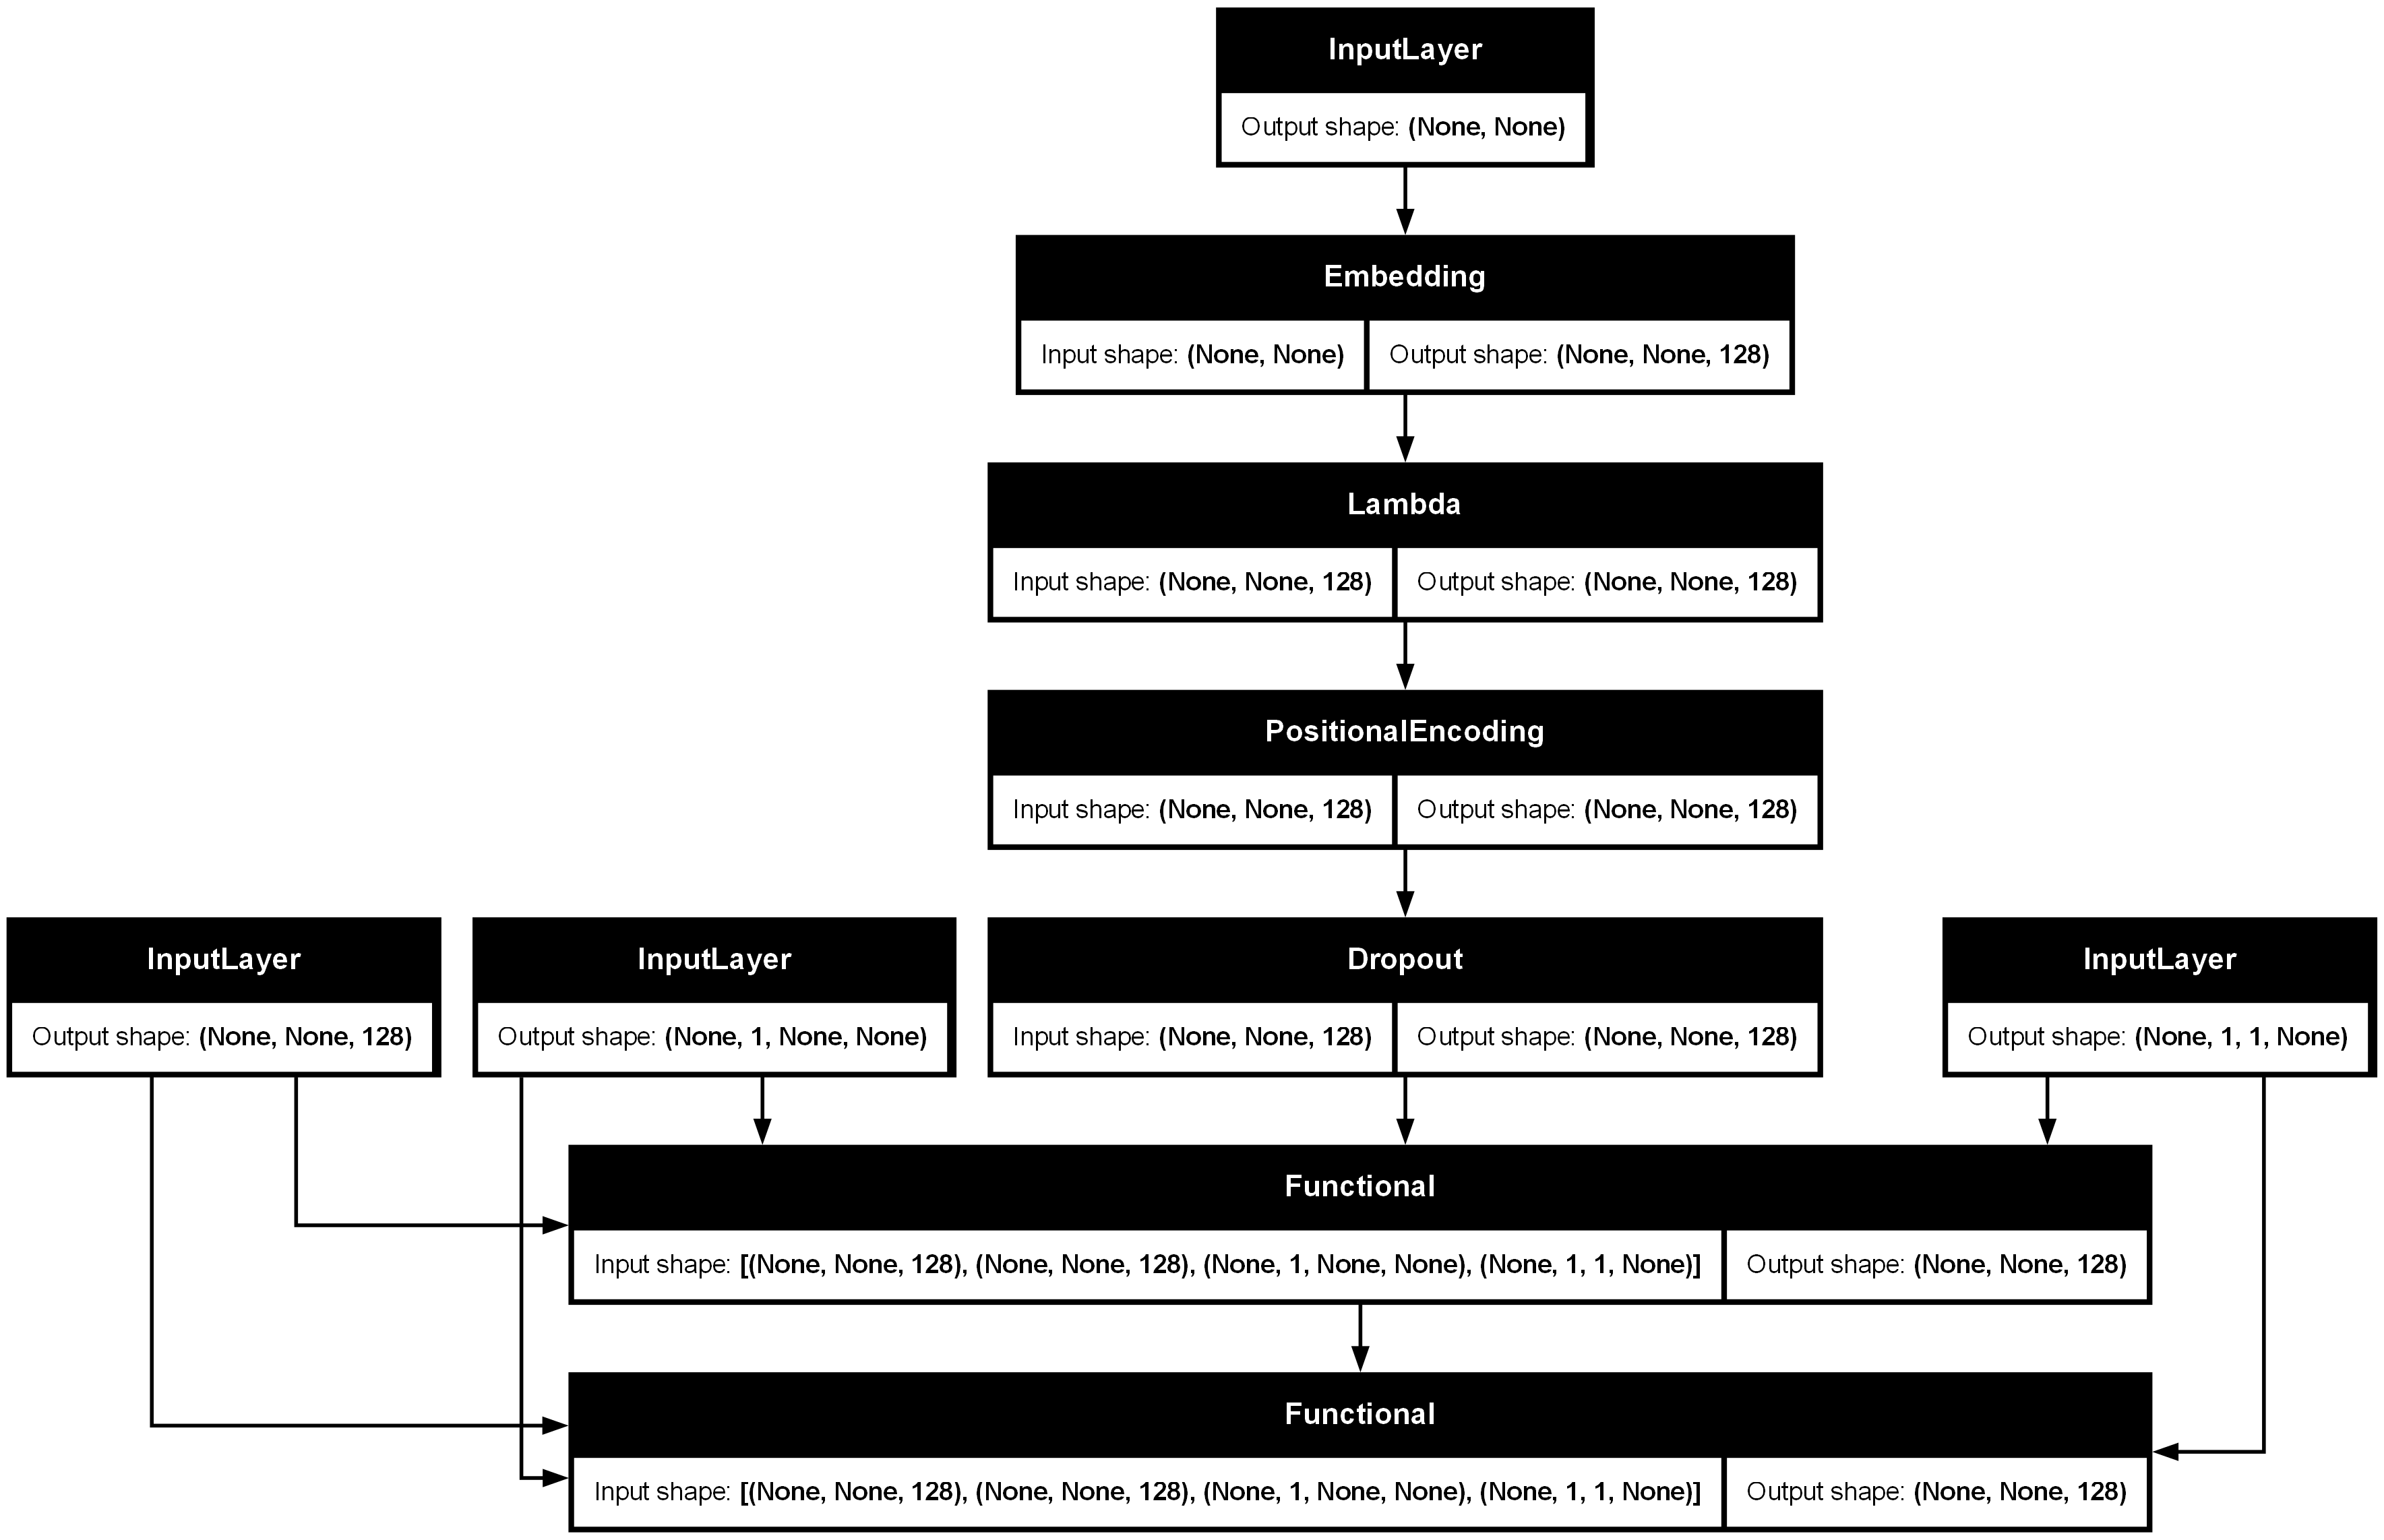

In [36]:
sample_decoder = decoder(
    vocab_size=8192,
    num_layers=2,
    units=512,
    d_model=128,
    num_heads=4,
    dropout=0.3,
    name="sample_decoder")

tf.keras.utils.plot_model(
    sample_decoder, to_file='decoder.png', show_shapes=True)

### Transformer

El Transformer consiste en el codificador, decodificador y una capa lineal final. La salida del decodificador es la entrada a la capa lineal y se devuelve su salida.

In [37]:
def transformer(vocab_size,
                num_layers,
                units,
                d_model,
                num_heads,
                dropout,
                name="transformer"):
  inputs = tf.keras.Input(shape=(None,), name="inputs")
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  enc_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='enc_padding_mask')(inputs)
  # mask the future tokens for decoder inputs at the 1st attention block
  look_ahead_mask = tf.keras.layers.Lambda(
      create_look_ahead_mask,
      output_shape=(1, None, None),
      name='look_ahead_mask')(dec_inputs)
  # mask the encoder outputs for the 2nd attention block
  dec_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='dec_padding_mask')(inputs)

  enc_outputs = encoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[inputs, enc_padding_mask])

  dec_outputs = decoder(
      vocab_size=vocab_size,
      num_layers=num_layers,
      units=units,
      d_model=d_model,
      num_heads=num_heads,
      dropout=dropout,
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)

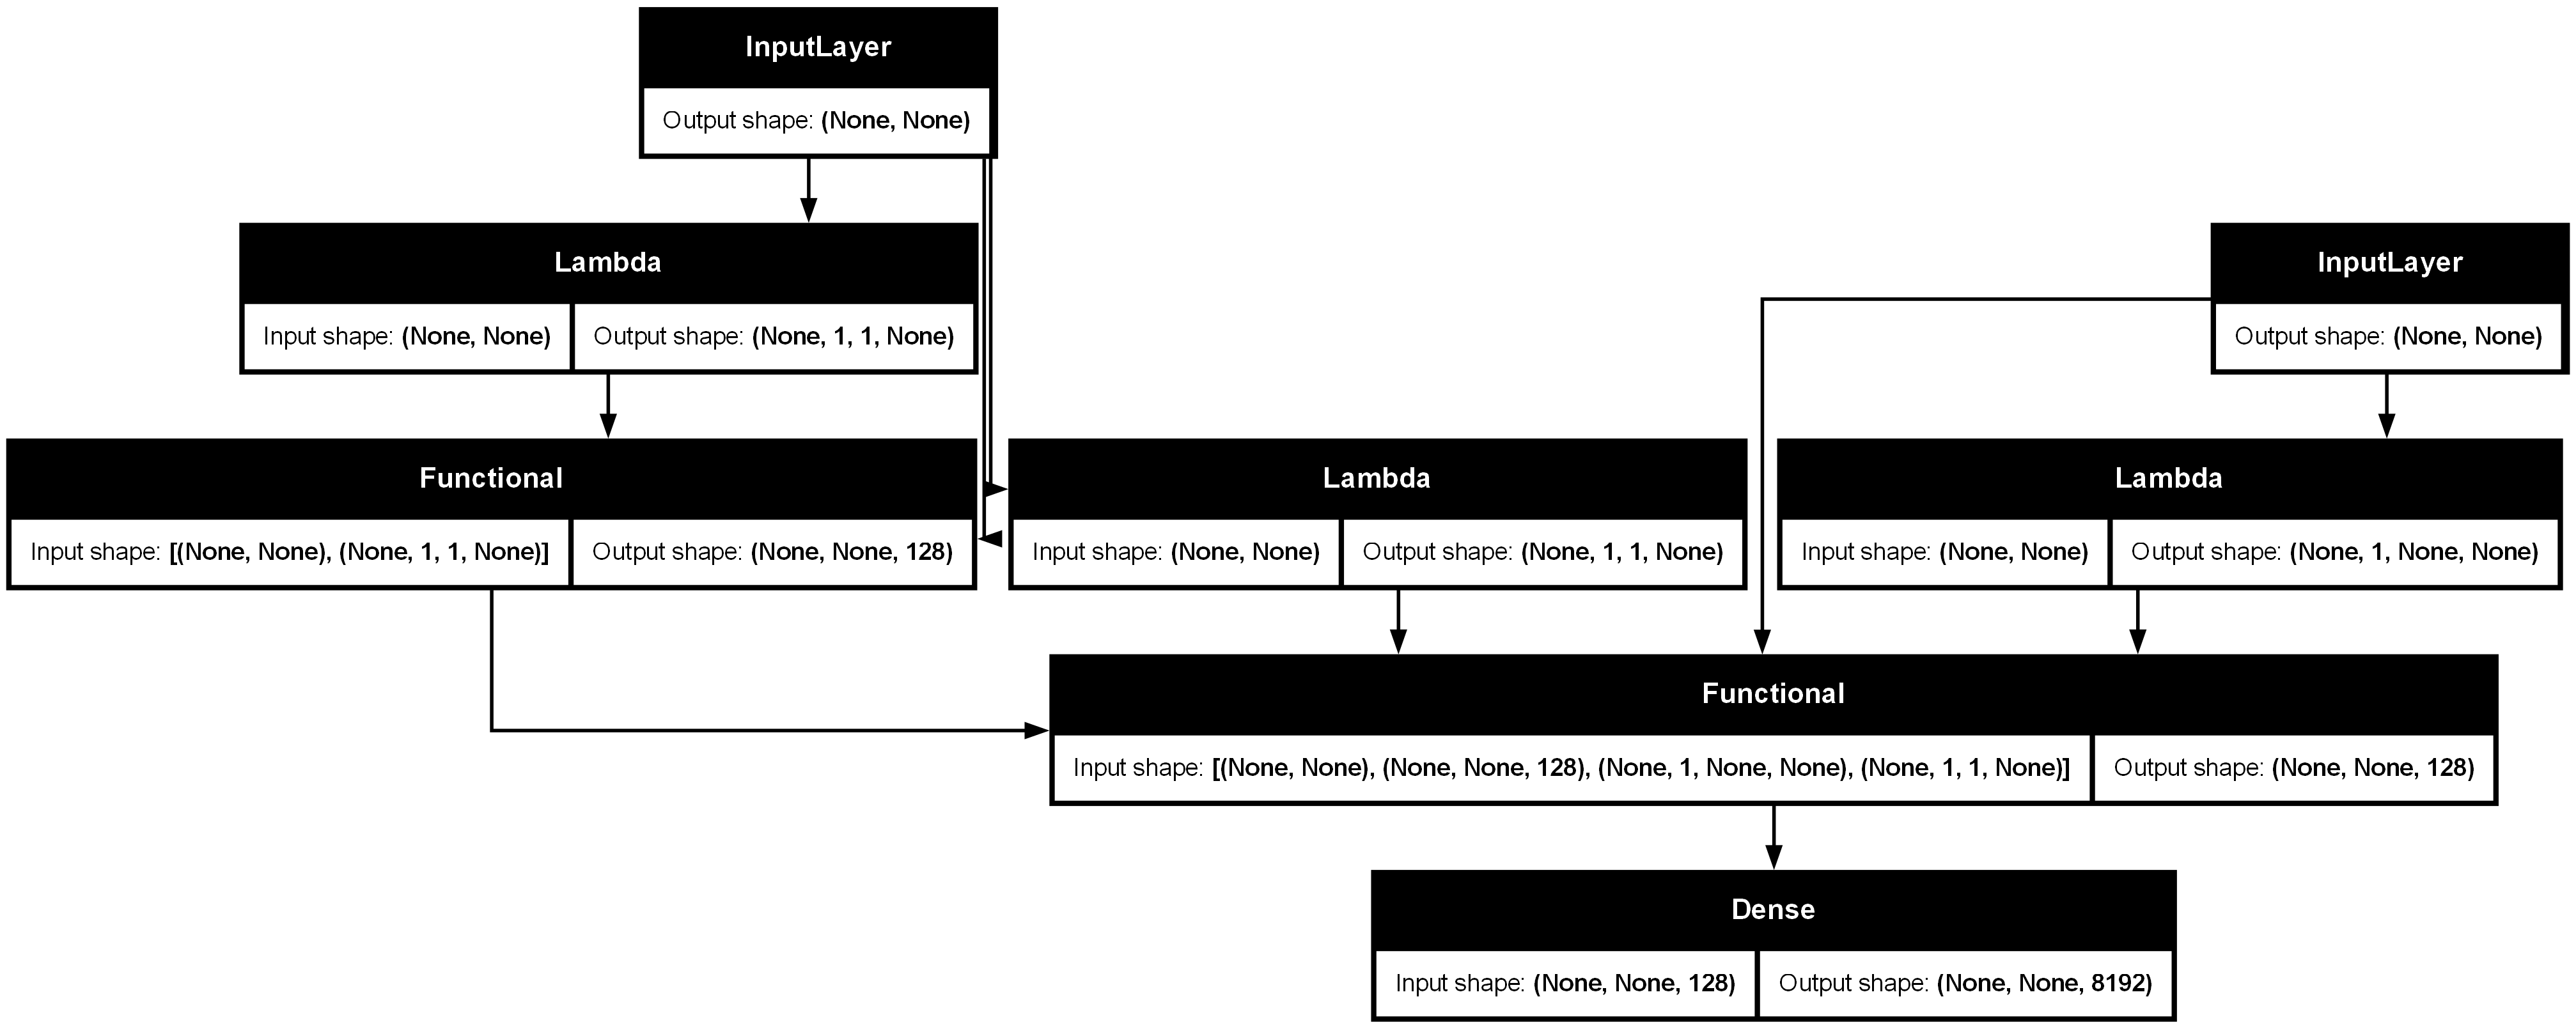

In [38]:
sample_transformer = transformer(
    vocab_size=8192,
    num_layers=4,
    units=512,
    d_model=128,
    num_heads=4,
    dropout=0.3,
    name="sample_transformer")

tf.keras.utils.plot_model(
    sample_transformer, to_file='transformer.png', show_shapes=True)

## <span style="color:blue"> Entrenamiento del modelo</span>

### Función de pérdida

Dado que las secuencias de destino se rellenan, es importante aplicar una máscara de relleno al calcular la pérdida.

In [39]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  
  loss = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction='none')(y_true, y_pred)

  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)

  return tf.reduce_mean(loss)

### Ajuste de la rate de aprendizaje

Use el optimizador de Adam con un programador de tasa de aprendizaje personalizado de acuerdo con la fórmula en el [artículo](https://arxiv.org/abs/1706.03762).

$$\Large{lrate = d_{model}^{-0.5} * min(step{\_}num^{-0.5}, step{\_}num * warmup{\_}steps^{-1.5})}$$

In [40]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # Convert values to float32 before mathematical operations
        step = tf.cast(step, tf.float32)
        d_model = tf.cast(self.d_model, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        
        return tf.math.rsqrt(d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):
        return {
            "d_model": self.d_model,
            "warmup_steps": self.warmup_steps,
        }

Text(0.5, 0, 'Paso de entrenamiento')

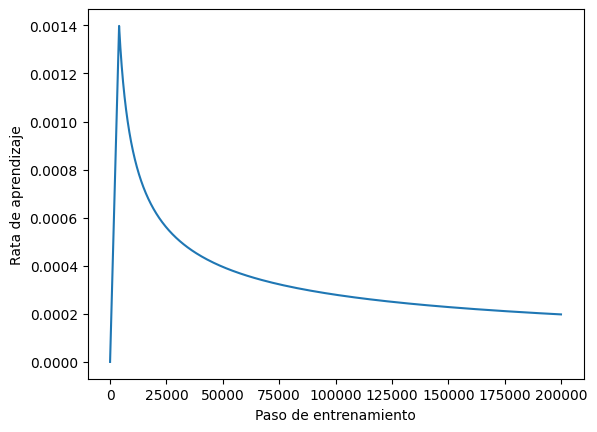

In [41]:
sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Rata de aprendizaje")
plt.xlabel("Paso de entrenamiento")

### Inicializar y compilar modelo

Inicialice y compile el modelo con nuestra tasa de aprendizaje personalizada predefinida y el optimizador de Adam en el ámbito de la estrategia.

In [42]:
# clear backend
tf.keras.backend.clear_session()

learning_rate = CustomSchedule(D_MODEL)

optimizer = tf.keras.optimizers.Adam(
    learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

def accuracy(y_true, y_pred):
  # ensure labels have shape (batch_size, MAX_LENGTH - 1)
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  return tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

# initialize and compile model within strategy scope
with strategy.scope():
  model = transformer(
      vocab_size=VOCAB_SIZE,
      num_layers=NUM_LAYERS,
      units=UNITS,
      d_model=D_MODEL,
      num_heads=NUM_HEADS,
      dropout=DROPOUT)

  model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])

model.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inputs          │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_padding_mask    │ (None, 1, 1,      │          0 │ inputs[0][0]      │
│ (Lambda)            │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, None, 256) │  3,173,376 │ inputs[0][0],     │
│ (Functional)        │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ look_ahead_mask     │ (None, 1, None,   │          0 │ dec_inputs[0][0]  │
│ (Lambda)            │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_padding_mask    │ (None, 1, 1,      │          0 │ inputs[0][0]      │
│ (Lambda)            │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, None, 256) │  3,700,736 │ dec_inputs[0][0], │
│ (Functional)        │                   │            │ encoder[0][0],    │
│                     │                   │            │ look_ahead_mask[… │
│                     │                   │            │ dec_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs (Dense)     │ (None, None,      │  2,127,446 │ decoder[0][0]     │
│                     │ 8278)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,001,558 (34.34 MB)

 Trainable params: 9,001,558 (34.34 MB)

 Non-trainable params: 0 (0.00 B)

### Ajusta el modelo

Entrene a nuestro transformador simplemente llamando a `model.fit()`

In [ ]:
model.fit(dataset, epochs=EPOCHS)

In [ ]:
# Keras 3: exporta un SavedModel para inferencia sin repetir el entrenamiento.
model.export("transformer_model")

In [45]:
model.save_weights("transformer_weights.weights.h5")

## <span style="color:blue">Evaluación y predicción</span>

Los siguientes pasos se utilizan para la evaluación:

* Aplique el mismo método de preprocesamiento que usamos para crear nuestro conjunto de datos para la oración de entrada.
* Tokenice la oración de entrada y agregue `START_TOKEN` y `END_TOKEN`.
* Calcule las máscaras de relleno y las máscaras anticipadas.
* El decodificador luego emite las predicciones mirando la salida del codificador y su propia salida.
* Seleccione la última palabra y calcule el argmax de eso.
* Concatenar la palabra predicha a la entrada del decodificador y pasarla al decodificador.
* En este enfoque, el decodificador predice la siguiente palabra basándose en las palabras anteriores que predijo.

Nota: El modelo utilizado aquí tiene menos capacidad y se entrenó en un subconjunto del conjunto de datos completo, por lo que su rendimiento se puede mejorar aún más.

In [46]:
def evaluate(sentence):
  sentence = preprocess_sentence(sentence)

  sentence = tf.expand_dims(
      START_TOKEN + tokenizer.encode(sentence) + END_TOKEN, axis=0)

  output = tf.expand_dims(START_TOKEN, 0)

  for i in range(MAX_LENGTH):
    predictions = model(inputs=[sentence, output], training=False)

    # select the last word from the seq_len dimension
    predictions = predictions[:, -1:, :]
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

    # return the result if the predicted_id is equal to the end token
    if tf.equal(predicted_id, END_TOKEN[0]):
      break

    # concatenated the predicted_id to the output which is given to the decoder
    # as its input.
    output = tf.concat([output, predicted_id], axis=-1)

  return tf.squeeze(output, axis=0)


def predict(sentence):
  prediction = evaluate(sentence)

  predicted_sentence = tokenizer.decode(
      [i for i in prediction if i < tokenizer.vocab_size])

  print('Input: {}'.format(sentence))
  print('Output: {}'.format(predicted_sentence))

  return predicted_sentence

Let's test our model!

In [47]:
output = predict('Where have you been?')

Input: Where have you been?
Output: i am not a murderer . i am just a little out of here .


In [48]:
output = predict("It's a trap")

Input: It's a trap
Output: i am not ready to be a bank teller . i am not ready to be a good idea to be a lot of time .


In [51]:
# feed the model with its previous output
sentence = 'I am not crazy, my mother had me tested.'
for _ in range(5):
  sentence = predict(sentence)
  print('')

Input: I am not crazy, my mother had me tested.
Output: you are a fool .

Input: you are a fool .
Output: i am not ready to be a lot of money .

Input: i am not ready to be a lot of money .
Output: you are a good man .

Input: you are a good man .
Output: i am not a little late .

Input: i am not a little late .
Output: you are a good man .



## <span style="color:blue"> Resumen</span>

Aquí estamos, hemos implementado un Transformador en TensorFlow 2.0 en alrededor de 500 líneas de código.

En este tutorial, nos enfocamos en los dos enfoques diferentes para implementar modelos complejos con API funcional y subclases de modelos, y cómo incorporarlos.

¡Intente usar un conjunto de datos diferente o hiperparámetros para entrenar el Transformador! Gracias por leer.